# Heart Disease

# libraries

In [112]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_regression

from sklearn.model_selection import train_test_split

# Regression
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#classification
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Read dataset

In [83]:
filepath = '/content/drive/MyDrive/AI ML Course/Data/heart_disease.csv'
df_heart = pd.read_csv(filepath)
df_heart

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


# EDA

In [84]:
# Check the number of rows and columns in the dataset
df_heart.shape

(1025, 14)

In [85]:
# Display information about the DataFrame
df_heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [86]:
# Display summary statistics of the numerical columns
df_heart.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


### Plots

In [87]:
# collecting numerical columns
num_cols = []
# collecting categorical columns
cat_cols = []

In [88]:
# Select the names of all numerical columns
num_cols = df_heart.select_dtypes(include=['int','float']).columns
# Select the names of all categorical columns
cat_cols = df_heart.select_dtypes(include=['object','bool']).columns

In [89]:
num_cols # print numerical columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [90]:
cat_cols # print categorical columns

Index([], dtype='object')

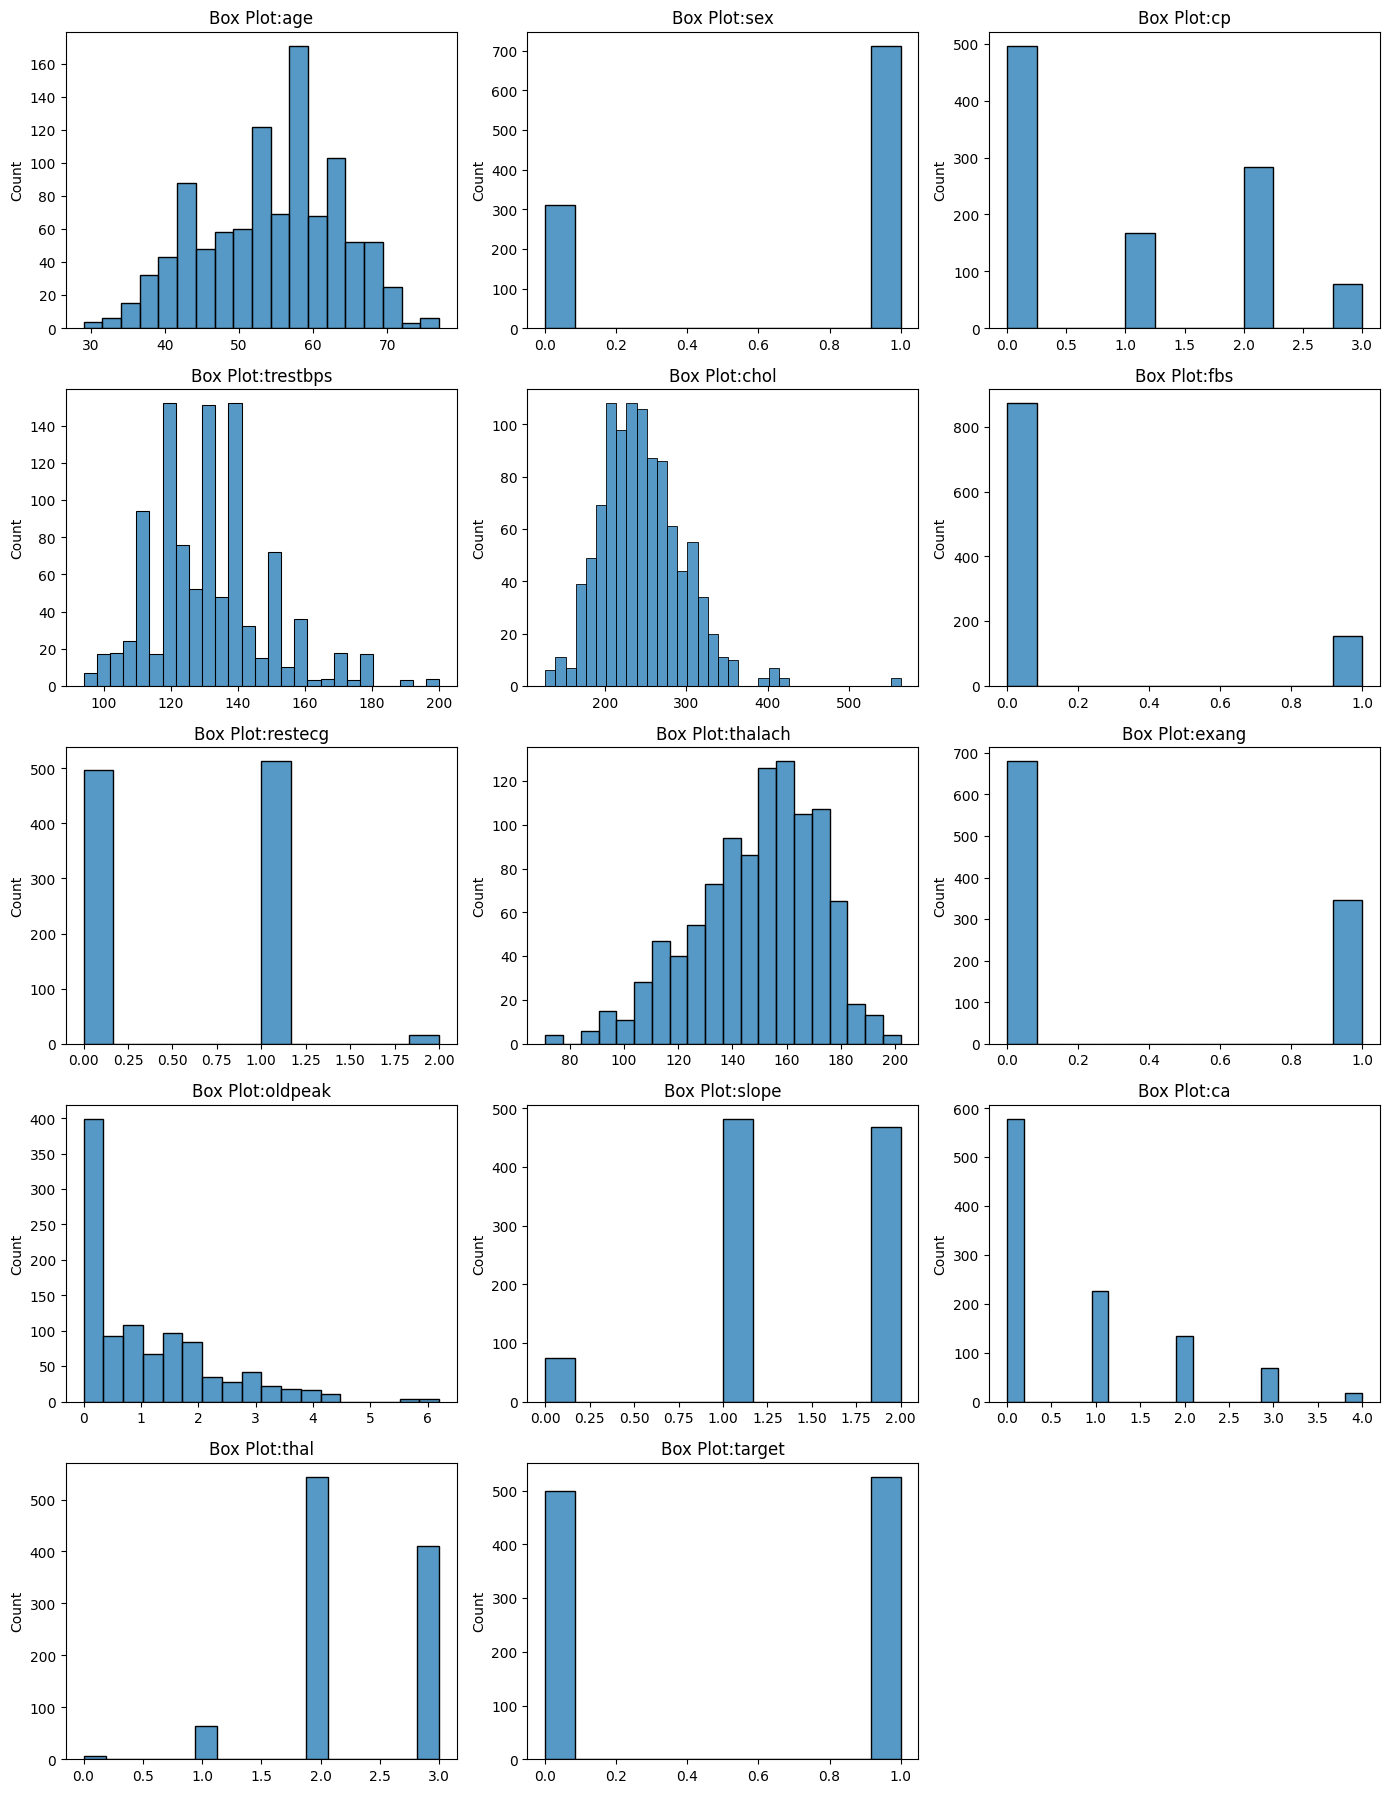

In [91]:
# Create histograms for each numerical column to understand the distribution of values
plt.figure(figsize=(14,50))

for i,col in enumerate(num_cols):
  plt.subplot(14,3,i+1)
  sns.histplot(df_heart[col])
  plt.title(f'Box Plot:{col}')
  plt.xlabel('')

plt.tight_layout()
plt.show()

### Visualisation

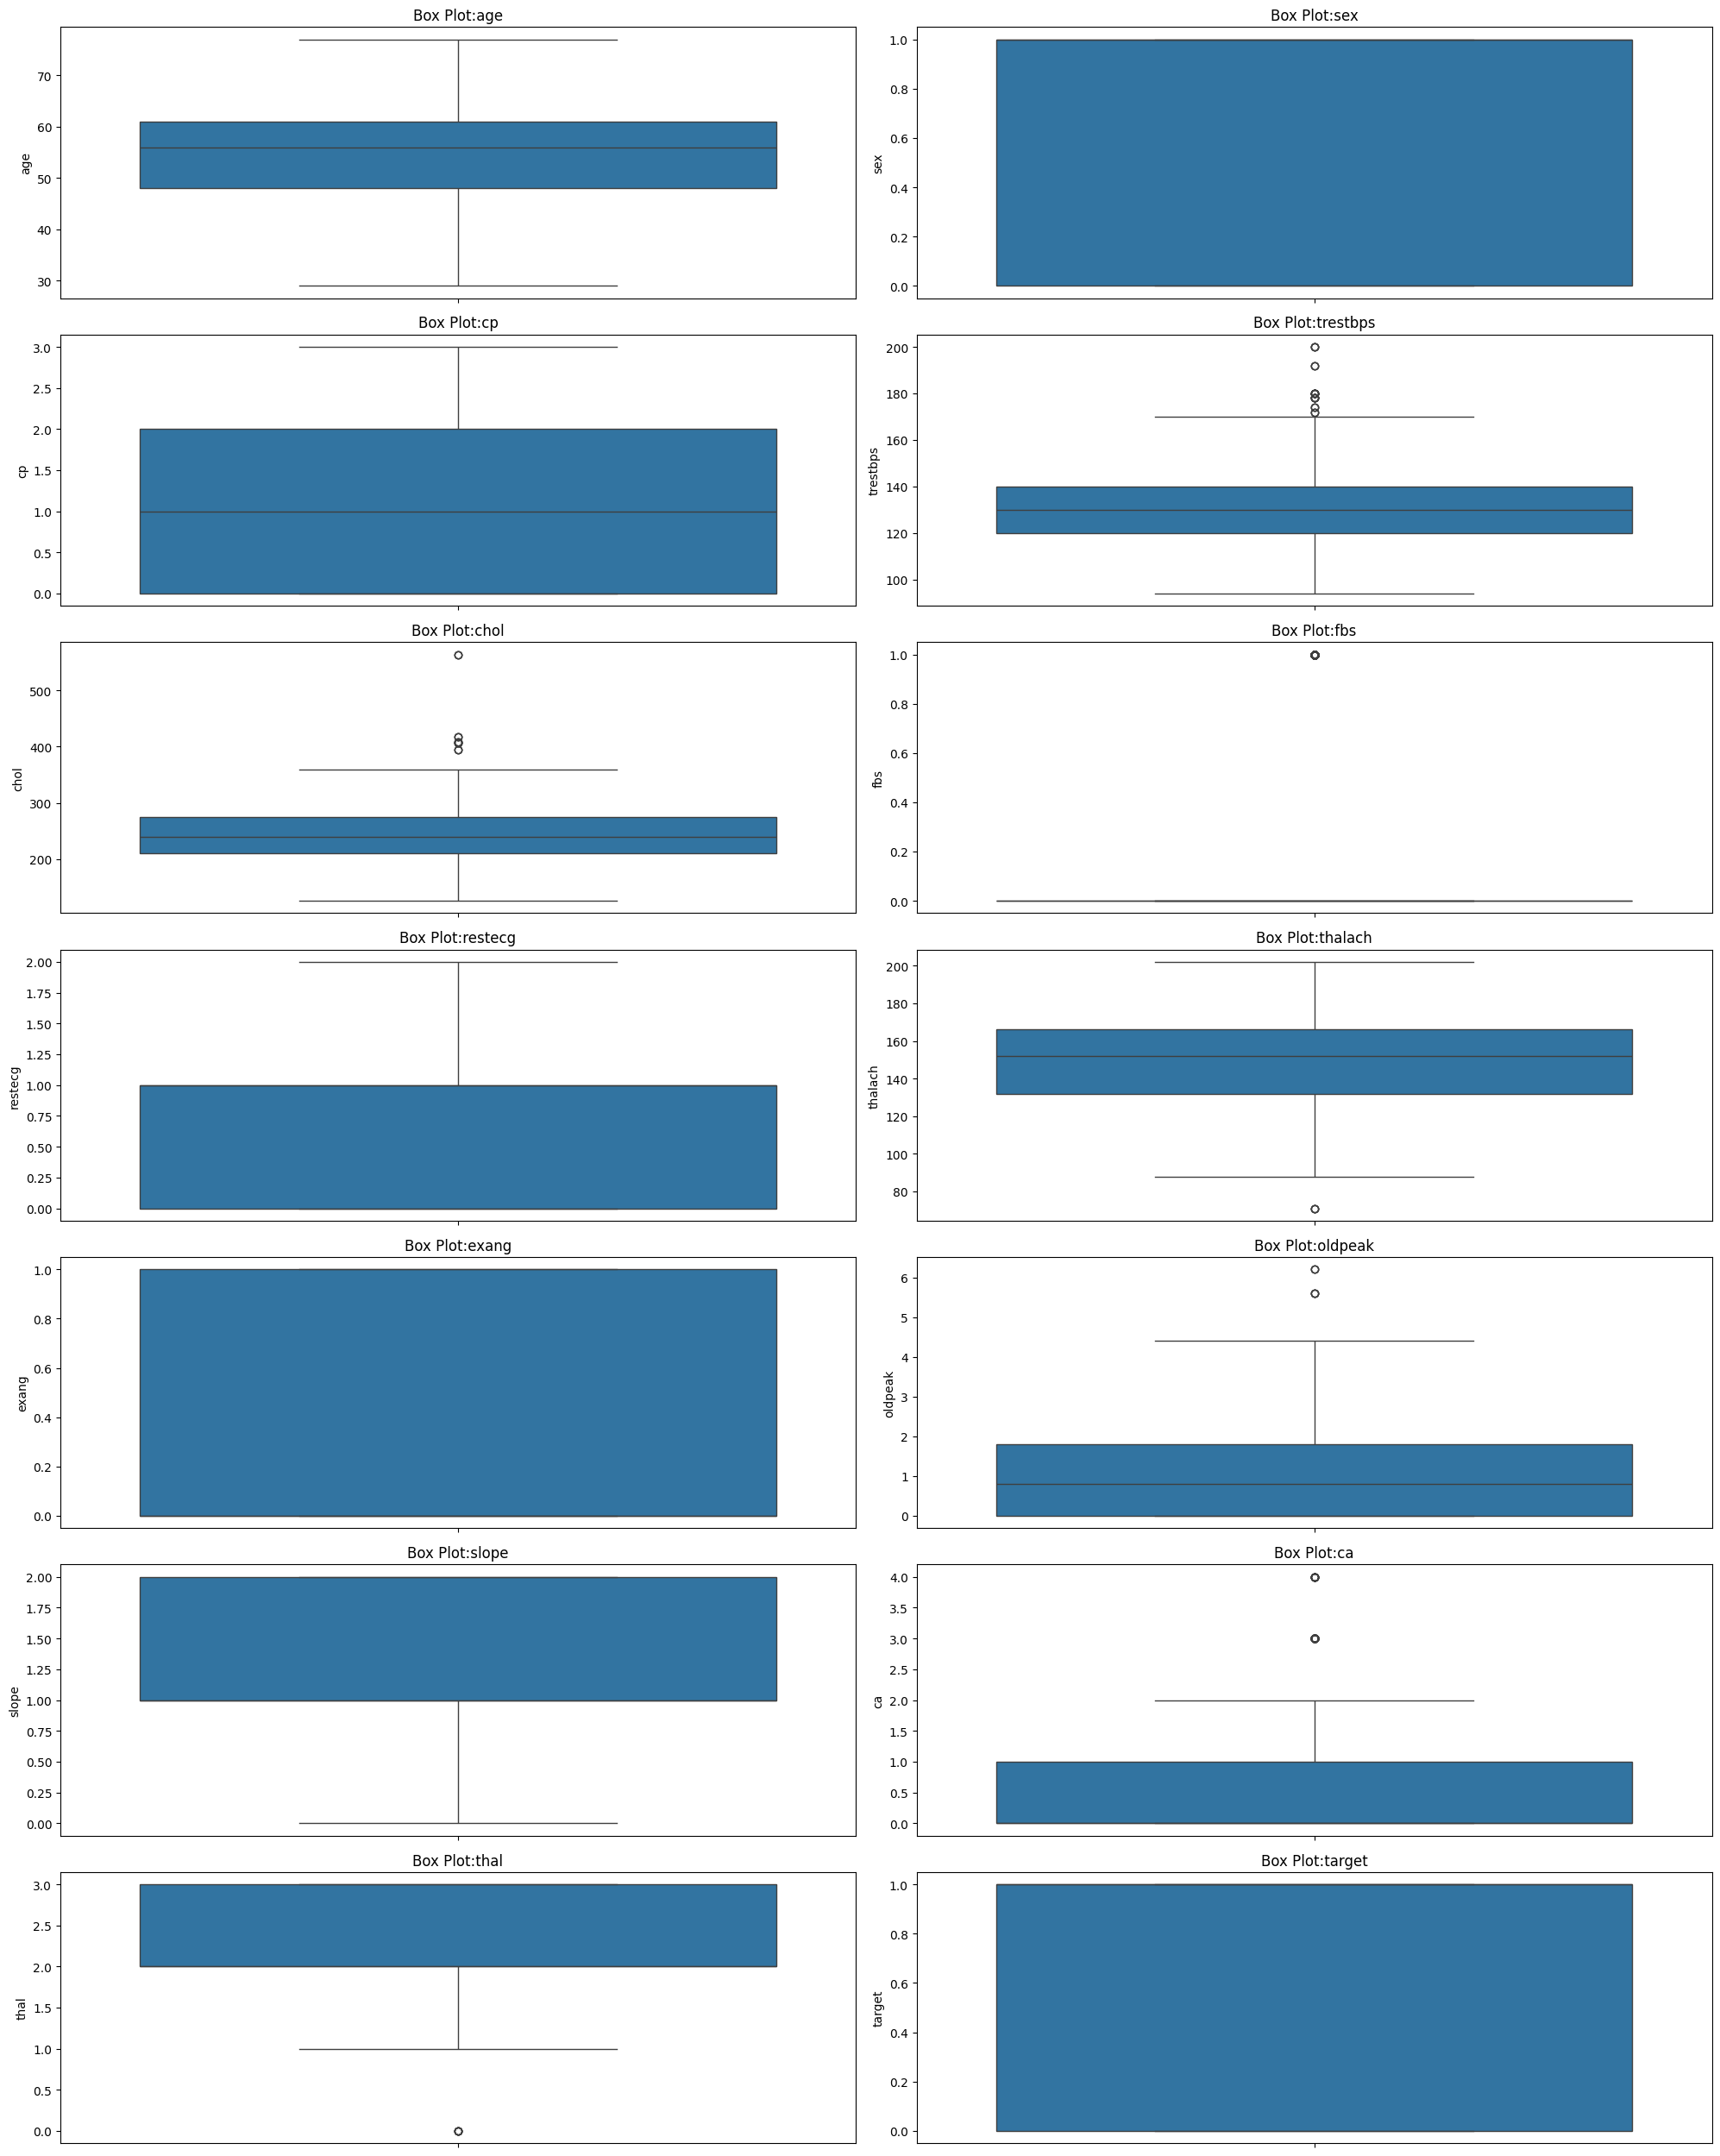

In [92]:
# Create box plots for all numerical features to find outliers
plt.figure(figsize=(20,50))

for i,col in enumerate(num_cols):
  plt.subplot(14,2,i+1)
  sns.boxplot(df_heart[col])
  plt.title(f'Box Plot:{col}')
  plt.xlabel('')

plt.tight_layout()
plt.show()

In [93]:
outlier_cols = ['thal', 'oldpeak', 'trestbps', 'chol', 'thalach', 'fbs', 'ca']

for i in outlier_cols:
  Q1 = df_heart[i].quantile(0.25)
  Q3 = df_heart[i].quantile(0.75)
  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  print(f"Q1: {Q1}")
  print(f"Q3: {Q3}")
  print(f"IQR: {IQR}")
  print(f"Lower Bound: {lower_bound}")
  print(f"Upper Bound: {upper_bound}")

Q1: 2.0
Q3: 3.0
IQR: 1.0
Lower Bound: 0.5
Upper Bound: 4.5
Q1: 0.0
Q3: 1.8
IQR: 1.8
Lower Bound: -2.7
Upper Bound: 4.5
Q1: 120.0
Q3: 140.0
IQR: 20.0
Lower Bound: 90.0
Upper Bound: 170.0
Q1: 211.0
Q3: 275.0
IQR: 64.0
Lower Bound: 115.0
Upper Bound: 371.0
Q1: 132.0
Q3: 166.0
IQR: 34.0
Lower Bound: 81.0
Upper Bound: 217.0
Q1: 0.0
Q3: 0.0
IQR: 0.0
Lower Bound: 0.0
Upper Bound: 0.0
Q1: 0.0
Q3: 1.0
IQR: 1.0
Lower Bound: -1.5
Upper Bound: 2.5


# Preprocessing

## Cleaning

### Outlier handling

In [94]:
# clipping

for i in outlier_cols:
  Q1 = df_heart[i].quantile(0.25)
  Q3 = df_heart[i].quantile(0.75)
  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  df_heart[i] = df_heart[i].clip(lower_bound, upper_bound)
  outliers = ((df_heart[i] < lower_bound) | (df_heart[i] > upper_bound))
  print(f'outliers: {outliers.sum()}')

outliers: 0
outliers: 0
outliers: 0
outliers: 0
outliers: 0
outliers: 0
outliers: 0


### Missing value

In [95]:
# Count the number of missing values in each column
df_heart.isna().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


### Duplicate value

In [96]:
# Count the total number of duplicate rows in the DataFrame
df_heart.duplicated().sum()

np.int64(723)

In [97]:
df_heart.drop_duplicates(inplace=True) # dropping duplicates

In [98]:
df_heart.duplicated().sum() # after removal of duplicates

np.int64(0)

# Transformation

## Mutual Info

In [99]:
y = df_heart['chol']
X = df_heart.drop(columns=['chol', 'target'])
mutual_info = mutual_info_regression(X, y, random_state=42)
mutual_info = pd.DataFrame({'features': X.columns, 'Mutual info': mutual_info})
mutual_info


,features,Mutual info
0,age,0.004532
1,sex,0.039666
2,cp,0.040097
3,trestbps,0.025619
4,fbs,0.002241
5,restecg,0.011273
6,thalach,0.062058
7,exang,0.000000
8,oldpeak,0.005600
9,slope,0.000000


## Encoding

In [100]:
# One-hot encoding for multi-category variables

df_heart = pd.get_dummies(
    df_heart,
    columns=['cp', 'restecg', 'thal'],
    drop_first=True,
    dtype=int
)

df_heart.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,slope,ca,target,cp_1,cp_2,cp_3,restecg_1,restecg_2,thal_1.0,thal_2.0,thal_3.0
0,52,1,125,212,0,168,0,1.0,2,2.0,0,0,0,0,1,0,0,0,1
1,53,1,140,203,0,155,1,3.1,0,0.0,0,0,0,0,0,0,0,0,1
2,70,1,145,174,0,125,1,2.6,0,0.0,0,0,0,0,1,0,0,0,1
3,61,1,148,203,0,161,0,0.0,2,1.0,0,0,0,0,1,0,0,0,1
4,62,0,138,294,0,106,0,1.9,1,2.5,0,0,0,0,1,0,0,1,0


## Scaling

In [103]:
scaler = StandardScaler()

scale_columns = ['trestbps', 'chol', 'thalach', 'oldpeak', 'age']
df_heart[scale_columns] = scaler.fit_transform(df_heart[scale_columns])
df_heart.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,slope,ca,target,cp_1,cp_2,cp_3,restecg_1,restecg_2,thal_1.0,thal_2.0,thal_3.0
0,-0.267966,1,-0.377511,-0.703851,0,0.808363,0,-0.030009,2,2.0,0,0,0,0,1,0,0,0,1
1,-0.157260,1,0.527318,-0.893583,0,0.237155,1,1.835836,0,0.0,0,0,0,0,0,0,0,0,1
2,1.724733,1,0.828927,-1.504942,0,-1.081019,1,1.391587,0,0.0,0,0,0,0,1,0,0,0,1
3,0.728383,1,1.009893,-0.893583,0,0.500790,0,-0.918506,2,1.0,0,0,0,0,1,0,0,0,1
4,0.839089,0,0.406674,1.024818,0,-1.915862,0,0.769639,1,2.5,0,0,0,0,1,0,0,1,0


# Train Test Split

In [106]:
# Features and target
X = df_heart.drop(columns='target')
y = df_heart['target']

# Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Check the shapes
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (241, 18)
X_test : (61, 18)
y_train: (241,)
y_test : (61,)


In [108]:
# Features and target for Regression
X_reg = df_heart.drop(columns=['chol'])
y_reg = df_heart['chol']

# Train-Test Split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg,
    test_size=0.2,
    random_state=42
)

print("X_train_reg:", X_train_reg.shape)
print("X_test_reg :", X_test_reg.shape)
print("y_train_reg:", y_train_reg.shape)
print("y_test_reg :", y_test_reg.shape)

X_train_reg: (241, 18)
X_test_reg : (61, 18)
y_train_reg: (241,)
y_test_reg : (61,)


### Regression

In [110]:
# Create and train Linear Regression model
lr_reg = LinearRegression()

lr_reg.fit(X_train_reg, y_train_reg)

# Prediction
y_pred_lr_reg = lr_reg.predict(X_test_reg)

# Evaluation
lr_mae = mean_absolute_error(y_test_reg, y_pred_lr_reg)
lr_mse = mean_squared_error(y_test_reg, y_pred_lr_reg)
lr_r2 = r2_score(y_test_reg, y_pred_lr_reg)

print("Linear Regression")
print("MAE:", lr_mae)
print("MSE:", lr_mse)
print("R² Score:", lr_r2)

Linear Regression
MAE: 0.7105707064235457
MSE: 0.8332647272333816
R² Score: -0.1698476754398046


### SVM Regression

In [ ]:
svm_reg = SVR()

svm_reg.fit(X_train_reg, y_train_reg)

# Prediction
y_pred_svm = svm_reg.predict(X_test_reg)

# Evaluation
svm_mae = mean_absolute_error(y_test_reg, y_pred_svm)
svm_mse = mean_squared_error(y_test_reg, y_pred_svm)
svm_r2 = r2_score(y_test_reg, y_pred_svm)

print("SVM Regression")
print("MAE:", svm_mae)
print("MSE:", svm_mse)
print("R² Score:", svm_r2)

### Random Forest Regression

In [111]:
rf_reg = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_reg.fit(X_train_reg, y_train_reg)

# Prediction
y_pred_rf_reg = rf_reg.predict(X_test_reg)

# Evaluation
rf_mae = mean_absolute_error(y_test_reg, y_pred_rf_reg)
rf_mse = mean_squared_error(y_test_reg, y_pred_rf_reg)
rf_r2 = r2_score(y_test_reg, y_pred_rf_reg)

print("Random Forest Regression")
print("MAE:", rf_mae)
print("MSE:", rf_mse)
print("R² Score:", rf_r2)

Random Forest Regression
MAE: 0.6944155126879323
MSE: 0.7844401038958039
R² Score: -0.10130118565218171


### Classification